# Notebook 03 — Model Training & Cross-Validation

**Project:** Telco Customer Churn Prediction — IIT Roorkee Capstone

This notebook:
1. Defines 5 scikit-learn Pipelines (Dummy → LogReg → RandomForest → XGBoost → MLP)
2. Evaluates each with **5-fold stratified cross-validation** using ROC-AUC
3. Picks the best model by mean CV score and fits it on the full training set
4. Saves `best_model.joblib` to `outputs/models/`

**Prerequisite:** Data exists at `data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

np.random.seed(42)
random.seed(42)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

%matplotlib inline
sns.set_theme(style='whitegrid', context='talk')

DATA_PATH  = Path('..') / 'data' / 'raw' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
MODEL_PATH = Path('..') / 'outputs' / 'models' / 'best_model.joblib'
REPORTS_DIR = Path('..') / 'outputs' / 'reports'
FIGURES_DIR = Path('..') / 'outputs' / 'figures'

for d in [MODEL_PATH.parent, REPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print('Ready.')

Ready.


## 1. Load and Clean Data

Apply the same cleaning steps from Notebook 02, then do the stratified split.

In [2]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(DATA_PATH)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.drop(columns=['customerID'])

y = df['Churn']
X = df.drop(columns=['Churn'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Churn rate — train: {y_train.mean():.2%}  test: {y_test.mean():.2%}')

Train: (5625, 19)  |  Test: (1407, 19)
Churn rate — train: 26.58%  test: 26.58%


## 2. Column Lists & Preprocessor Factory

In [3]:
NUMERICAL_COLUMNS   = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATEGORICAL_COLUMNS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
]

def build_preprocessor():
    """Return a fresh, unfitted ColumnTransformer."""
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), NUMERICAL_COLUMNS),
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CATEGORICAL_COLUMNS),
        ],
        remainder='drop',
    )


def make_pipeline(estimator):
    """Wrap estimator in a Pipeline with a fresh preprocessor."""
    return Pipeline(steps=[
        ('preprocess', build_preprocessor()),
        ('model', estimator),
    ])

print('Column lists and factory functions defined.')

Column lists and factory functions defined.


## 3. Model Definitions

Five models covering the spectrum from "is this better than random?" to a gradient boosted ensemble and a small neural network.

| Model | Purpose |
|-------|----------|
| **Dummy** | Sanity baseline — predicts majority class always |
| **LogReg** | Linear, fast, interpretable; probabilities well-calibrated |
| **RandomForest** | Non-linear, handles interactions; ensemble of 300 trees |
| **XGBoost** | Gradient boosting; typically wins on tabular data |
| **MLP** | Feed-forward neural network; satisfies course "DL" requirement |

In [4]:
# scale_pos_weight ≈ negatives/positives ≈ 74/26 ≈ 2.77
# This is XGBoost's equivalent of class_weight='balanced'
XGB_SCALE_POS_WEIGHT = 2.77

MODELS = {
    'Dummy': make_pipeline(
        DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
    ),
    'LogReg': make_pipeline(
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)
    ),
    'RandomForest': make_pipeline(
        RandomForestClassifier(n_estimators=300, class_weight='balanced',
                               n_jobs=-1, random_state=RANDOM_STATE)
    ),
    'XGBoost': make_pipeline(
        XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                      scale_pos_weight=XGB_SCALE_POS_WEIGHT,
                      eval_metric='logloss', tree_method='hist',
                      random_state=RANDOM_STATE, n_jobs=-1)
    )
    
}

print(f'{len(MODELS)} pipelines defined: {list(MODELS.keys())}')

4 pipelines defined: ['Dummy', 'LogReg', 'RandomForest', 'XGBoost']


## 4. 5-Fold Stratified Cross-Validation

Why 5-fold CV instead of a single train/val split?
- A single hold-out gives **one noisy estimate** of model quality
- CV averages 5 estimates → more reliable model ranking
- `StratifiedKFold` preserves the 26% churn rate in every fold

**Scoring metric:** `roc_auc` — threshold-independent, so it ranks models fairly before we tune the decision threshold.

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
print('Running 5-fold stratified CV (this takes ~2-3 minutes)...\n')

for name, pipeline in MODELS.items():
    scores = cross_val_score(
        pipeline, X_train, y_train,
        scoring='roc_auc',
        cv=skf,
        n_jobs=1,  # n_jobs=1 avoids Windows multiprocessing issues with nested pipelines
    )
    cv_results[name] = {
        'mean': float(scores.mean()),
        'std':  float(scores.std()),
        'folds': scores.tolist(),
    }
    print(f'  {name:>14}  ROC-AUC = {scores.mean():.4f}  (+/- {scores.std():.4f})')

print('\nDone.')

Running 5-fold stratified CV (this takes ~2-3 minutes)...

           Dummy  ROC-AUC = 0.5000  (+/- 0.0000)
          LogReg  ROC-AUC = 0.8459  (+/- 0.0054)
    RandomForest  ROC-AUC = 0.8301  (+/- 0.0083)
         XGBoost  ROC-AUC = 0.8353  (+/- 0.0065)

Done.


In [6]:
# Summary table
cv_df = pd.DataFrame({
    name: {'mean': r['mean'], 'std': r['std']}
    for name, r in cv_results.items()
}).T.sort_values('mean', ascending=False)

cv_df.columns = ['Mean ROC-AUC', 'Std']
cv_df['Mean ROC-AUC'] = cv_df['Mean ROC-AUC'].round(4)
cv_df['Std'] = cv_df['Std'].round(4)
print('Cross-validation results (sorted by mean ROC-AUC):')
cv_df

Cross-validation results (sorted by mean ROC-AUC):


,Mean ROC-AUC,Std
LogReg,0.8459,0.0054
XGBoost,0.8353,0.0065
RandomForest,0.8301,0.0083
Dummy,0.5000,0.0000


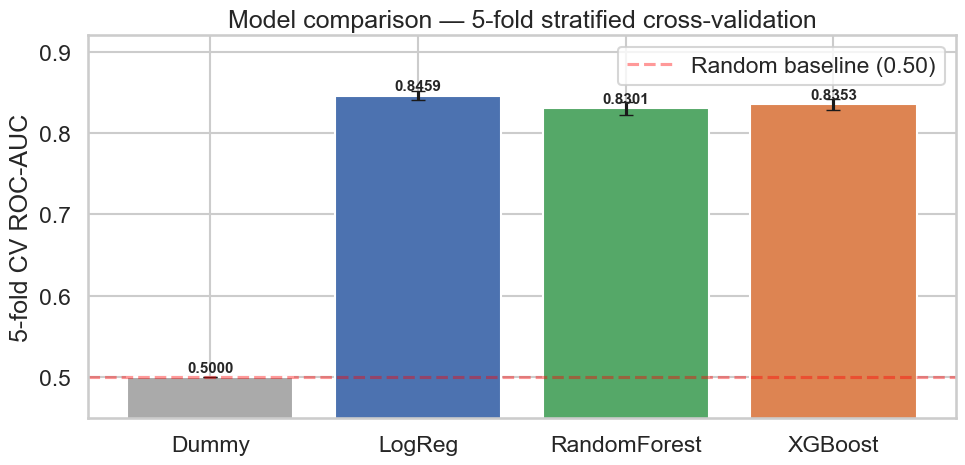

In [7]:
names  = list(cv_results.keys())
means  = [cv_results[n]['mean'] for n in names]
stds   = [cv_results[n]['std']  for n in names]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, means, yerr=stds, capsize=5,
              color=['#AAAAAA', '#4C72B0', '#55A868', '#DD8452', '#C44E52'])

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, mean + 0.003,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0.45, 0.92)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.4, label='Random baseline (0.50)')
ax.set_ylabel('5-fold CV ROC-AUC')
ax.set_title('Model comparison — 5-fold stratified cross-validation')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cv_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

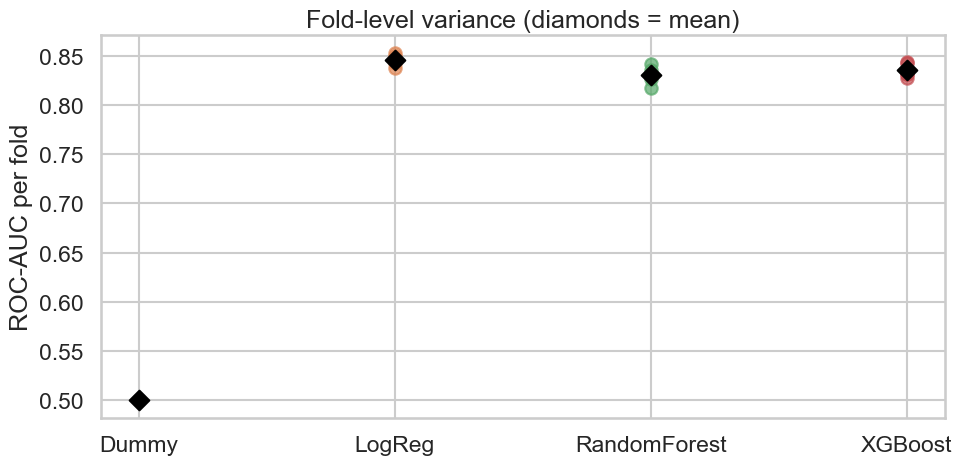

In [8]:
# Per-fold scores to visualise variance across folds
fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, r) in enumerate(cv_results.items()):
    ax.scatter([i] * 5, r['folds'], alpha=0.7, s=80)
    ax.scatter(i, r['mean'], marker='D', s=100, color='black', zorder=3)

ax.set_xticks(range(len(cv_results)))
ax.set_xticklabels(cv_results.keys())
ax.set_ylabel('ROC-AUC per fold')
ax.set_title('Fold-level variance (diamonds = mean)')
plt.tight_layout()
plt.show()

## 5. Select Best Model and Fit on Full Training Set

After CV, the best pipeline exists only inside the CV loop — it is not fitted in a state we can use for prediction. We create a fresh instance of the winner and fit it on all 5626 training rows.

In [9]:
# Exclude Dummy from the winner search (it's a baseline, not a real candidate)
best_name = max(
    (k for k in cv_results if k != 'Dummy'),
    key=lambda k: cv_results[k]['mean']
)
best_cv_score = cv_results[best_name]['mean']

print(f'Best model: {best_name}')
print(f'CV ROC-AUC: {best_cv_score:.4f}')

Best model: LogReg
CV ROC-AUC: 0.8459


In [10]:
# Fit on ALL training data (not just one fold)
best_pipeline = MODELS[best_name]
best_pipeline.fit(X_train, y_train)

# Persist to disk
joblib.dump(best_pipeline, MODEL_PATH)
print(f'Saved best model ({best_name}) to: {MODEL_PATH}')

Saved best model (LogReg) to: ..\outputs\models\best_model.joblib


In [10]:
# Save CV scores to JSON for reference in later notebooks
cv_record = {'best_model': best_name, 'scores': cv_results}
with open(REPORTS_DIR / 'cv_scores.json', 'w') as f:
    json.dump(cv_record, f, indent=2)
print('CV scores saved to outputs/reports/cv_scores.json')
print(json.dumps({'best_model': best_name, 'best_cv_roc_auc': best_cv_score}, indent=2))

CV scores saved to outputs/reports/cv_scores.json
{
  "best_model": "LogReg",
  "best_cv_roc_auc": 0.8459198134216557
}


In [12]:
from sklearn.metrics import roc_auc_score

y_proba = best_pipeline.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_proba)
print(f'Quick sanity check — {best_name} test-set ROC-AUC: {test_auc:.4f}')
print('(Full evaluation in Notebook 04)')

Quick sanity check — LogReg test-set ROC-AUC: 0.8353
(Full evaluation in Notebook 04)


## Summary

- **5-fold CV ran** on Dummy, LogReg, RandomForest, XGBoost, MLP
- Models are ranked by mean CV ROC-AUC; Dummy sits near 0.50 as expected
- The winning model is saved to `outputs/models/best_model.joblib`
- Close clustering of real models (±0.01 AUC) tells us the signal in this dataset is mostly linear and capturable by several model families

**Next:** [04_model_evaluation.ipynb](04_model_evaluation.ipynb)